In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Generate Data for Implementation

In [4]:
X_train = np.linspace(-1, 1, 20)
#-1 is starting point, 1 is ending point & 20 is no. of evenly spaced valued to generate.

In [5]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [6]:
X_test = np.linspace(-1, 1 , 20)

In [7]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

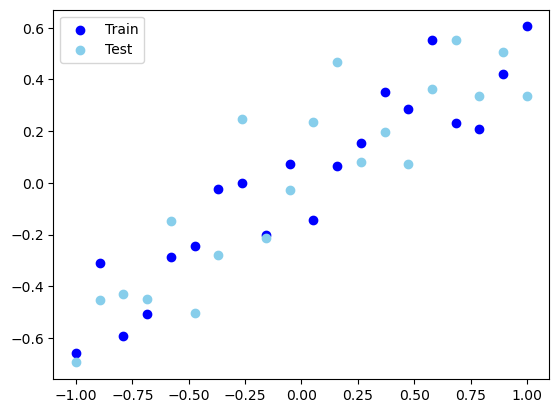

In [16]:
plt.scatter(X_train, y_train, c='blue', label='Train')
plt.scatter(X_test, y_test, c='skyblue', label='Test')
plt.legend()
plt.show()

# Regression Model

In [17]:
model_1 = Sequential()

In [21]:
model_1.add(Dense(128, input_dim=1, activation="relu"))      #input layer
model_1.add(Dense(128, activation="relu"))                   #hidden layer
model_1.add(Dense(1, activation="linear"))                   #output layer

In [22]:
adam = Adam(learning_rate=0.01)
#adam efficiently updates parameters to minimize the loss function like SGD

In [23]:
model_1.compile(loss='mse', optimizer=adam, metrics=['mse'])

In [24]:
history = model_1.fit(X_train, y_train, epochs=500, validation_data= (X_test, y_test), verbose=False)

In [25]:
#Evaluate the Model
_, train_mse = model_1.evaluate(X_train, y_train, verbose=0)
_, test_mse = model_1.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.004229594487696886, Test: 0.046590931713581085


#### Here We can clearly see that a large difference between Train and Test.

In [71]:
y_pred_1 = model_1.predict(X_test)
y_pred_1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


array([[-0.55609685],
       [-0.53486335],
       [-0.5136297 ],
       [-0.48792616],
       [-0.34721535],
       [-0.20344195],
       [-0.04380938],
       [-0.00422832],
       [-0.2099213 ],
       [ 0.06723302],
       [-0.1488014 ],
       [ 0.05222761],
       [ 0.14414419],
       [ 0.30189273],
       [ 0.35763863],
       [ 0.50324214],
       [ 0.22207497],
       [ 0.19475593],
       [ 0.39977345],
       [ 0.58938277]], dtype=float32)

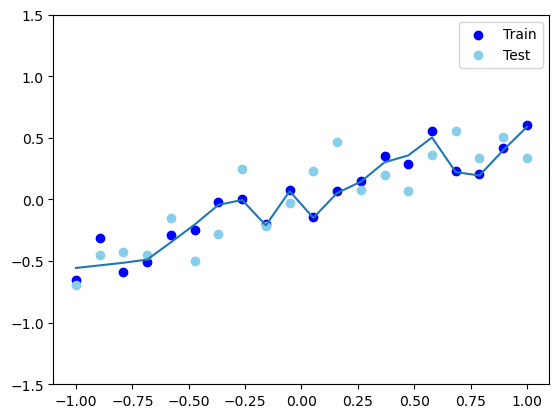

In [31]:
plt.figure()
plt.scatter(X_train, y_train, c='blue', label='Train')
plt.scatter(X_test, y_test, c='skyblue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

#### Here clearly display Overfitting on model, becuase model highly consider train data instead of understanding data.

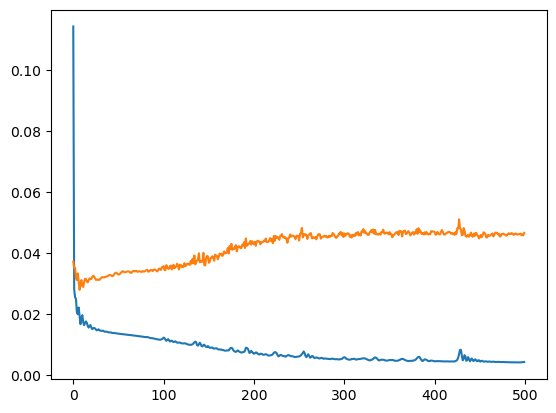

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Dropout Model

In [51]:
model_2 = Sequential()

In [52]:
model_2.add(Dense(128, input_dim=1, activation="relu"))
model_2.add(Dropout(0.2))
model_2.add(Dense(128, activation="relu"))
model_2.add(Dropout(0.2))
model_2.add(Dense(1, activation="linear"))
#0.2 means 20% neurons drop.

In [53]:
adam = Adam(learning_rate=0.01)

In [54]:
model_2.compile(loss='mse', optimizer=adam, metrics=['mse'])

In [55]:
drop_out_history = model_2.fit(X_train, y_train, epochs=500, validation_data = (X_test, y_test),verbose=False)

In [56]:
# evaluate the model
_, train_mse = model_2.evaluate(X_train, y_train, verbose=0)
_, test_mse = model_2.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.011133820749819279, Test: 0.03904043883085251


In [57]:
y_pred_2 = model_2.predict(X_test)
y_pred_2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[-0.55078095],
       [-0.50632894],
       [-0.4620686 ],
       [-0.40430477],
       [-0.32313913],
       [-0.21850824],
       [-0.08923601],
       [-0.06120437],
       [-0.06245622],
       [-0.06552318],
       [-0.06546409],
       [-0.00493626],
       [ 0.13100319],
       [ 0.30060738],
       [ 0.33939955],
       [ 0.33869195],
       [ 0.33582065],
       [ 0.33548194],
       [ 0.41584036],
       [ 0.52180713]], dtype=float32)

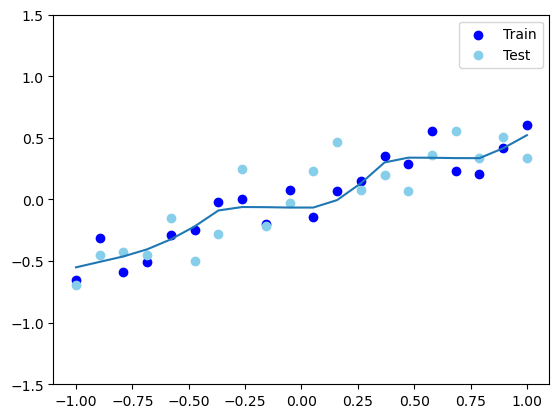

In [58]:
plt.figure()
plt.scatter(X_train, y_train, c='blue', label='Train')
plt.scatter(X_test, y_test, c='Skyblue', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

# Another Dropout Model

In [62]:
model_3 = Sequential()

In [63]:
model_3.add(Dense(128, input_dim=1, activation="relu"))
model_3.add(Dropout(0.5))
model_3.add(Dense(128, activation="relu"))
model_3.add(Dropout(0.5))
model_3.add(Dense(1, activation="linear"))

In [64]:
adam = Adam(learning_rate=0.01)

In [65]:
model_3.compile(loss='mse', optimizer=adam, metrics=['mse'])

In [66]:
drop_out_history = model_3.fit(X_train, y_train, epochs=500, 
                               validation_data = (X_test, y_test),
                               verbose=False)

In [67]:
# evaluate the model
_, train_mse = model_3.evaluate(X_train, y_train, verbose=0)
_, test_mse = model_3.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.01763404905796051, Test: 0.03967087343335152


#### Here We can clearly see that a difference between Train and Test decrease than last model.

In [68]:
y_pred_3 = model_3.predict(X_test)
y_pred_3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[-0.51921815],
       [-0.4707122 ],
       [-0.42323425],
       [-0.37581348],
       [-0.32518244],
       [-0.21923359],
       [-0.12434226],
       [-0.09162658],
       [-0.08549876],
       [-0.07860101],
       [-0.07153078],
       [-0.02078788],
       [ 0.11187159],
       [ 0.2219967 ],
       [ 0.24172443],
       [ 0.25754327],
       [ 0.2740064 ],
       [ 0.29344618],
       [ 0.31733516],
       [ 0.3492107 ]], dtype=float32)

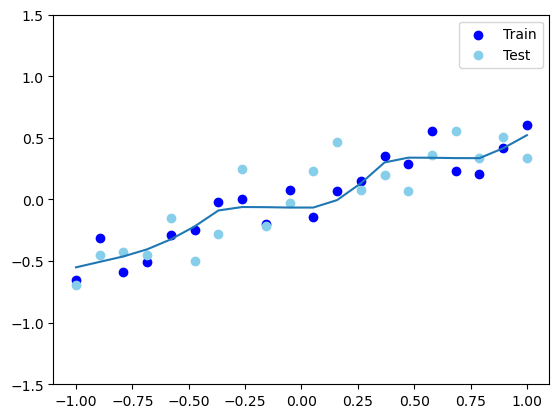

In [70]:
plt.figure()
plt.scatter(X_train, y_train, c='blue', label='Train')
plt.scatter(X_test, y_test, c='skyblue', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()